# SKA Low Fisher matrix for 2D power spectra

Nicholas Kern
<br>
nkern@umich.edu
<br>
July 2025

Based off of "Fisher_Tutorial_with_noise.ipynb" -> Giri, Gorce, Hothi

**Summary**:

This is somewhat of a HERA-style foreground avoidance treatment of the impact of foregrounds and systematics. We look at parameter constraints under different foreground wedge cuts, which are rough analogs for the severity of foregrounds / systematics and our ability to model / subtract them in the data.

1. Compute the 2D power spectra of the provided lightcones after applying the PSF beam smoothing (and optionally injecting thermal noise given an array layout and observation integration time).
2. Cut the 2D power spectra based on different assumptions of foreground subtraction and systematics.
    1. Perfect foreground removal (i.e. no wedge cut)
    2. Foreground cut out to 2 * 10 degree FWHM of primary beam (i.e. primary beam wedge)
    3. Foreground cut out to horizon (i.e. standard horizon wedge)
3. Flatten the 2D power spectra and compute the Fisher matrix.

Some high level notes:
- I only use k-modes in the range 0 < k_perp < 0.45 (PSF smoothing) and 0 < k_para < 0.75 (noise limited) for all forecasts.
- The beam cut is out to 10 degrees in zenith angle. The SKA-LOW station beam FWHM goes out to about 5 degrees, but I've doubled this to get down to < -25 dB in attenuation (arXiv:1602.01805).
- I use a blackmanharris tapering along the redshift direction when taking the 3D fft. 

In [1]:
%matplotlib inline
import numpy as np
import h5py
import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
import corner
from scipy.signal import windows

import os
import glob
import numpy as np

import tools21cm as t2c

In [2]:
from astropy.cosmology import Planck18 as cos

In [3]:
from utils import tau_to_kpara, bl_to_kperp, calc_2d_Pk, load_lc

# global parameters

In [4]:
# Folder where the data is stored
# ddir = '/data/cluster/agorce/SKA_chapter_simulations/'
ddir = '../../SKA_Chapter_simulations/' # This folder can be created inside the repository folder. It will be ignored during the git commit.
# File with fiducial lightcone
file = ddir+'Lightcone_FID_400_Samples.h5'

In [5]:
# cosmology
h = 0.6774

In [6]:
# Astro params
params = ['ION_Tvir_MIN','R_BUBBLE_MAX','HII_EFF_FACTOR']
Fisher_Param = ['$T_{Vir}$','$R_{Max}$','$\zeta$']
nparams = len(params)
# parameter values for fiducial simulation
fid = [pow(10,4.7),15,30]
# parameter range for derivatives
delta_params = [pow(10,4.740362689494244)-pow(10,4.653212513775344), 10, 10]

# Power spectrum params
nbins = 15

In [7]:
# simulation files
files = [ddir+'Lightcone_FID_400_Samples.h5']
[files.extend(
    [f'{ddir}Lightcone_{p}_400_Samples_Plus.h5', f'{ddir}Lightcone_{p}_400_Samples_Minus.h5']) for p in params]
print(files)

['../../SKA_Chapter_simulations/Lightcone_FID_400_Samples.h5', '../../SKA_Chapter_simulations/Lightcone_ION_Tvir_MIN_400_Samples_Plus.h5', '../../SKA_Chapter_simulations/Lightcone_ION_Tvir_MIN_400_Samples_Minus.h5', '../../SKA_Chapter_simulations/Lightcone_R_BUBBLE_MAX_400_Samples_Plus.h5', '../../SKA_Chapter_simulations/Lightcone_R_BUBBLE_MAX_400_Samples_Minus.h5', '../../SKA_Chapter_simulations/Lightcone_HII_EFF_FACTOR_400_Samples_Plus.h5', '../../SKA_Chapter_simulations/Lightcone_HII_EFF_FACTOR_400_Samples_Minus.h5']


In [8]:
# Read h5py file for metadata
with h5py.File(files[0], 'r') as f:
    frequencies = f['frequencies'][...]
    redshifts = f['redshifts'][...]
    box_length = float(f['box_length'][0]) / h  # Mpc
    box_dim = int(f['ngrid'][0])
    ngrid = int(f['ngrid'][0])  # number of pixels along the sky patch
    n_samp = int(f['nrealisations'][0])
nfreq = frequencies.size
print(f'Lightcone runs from z={redshifts.min():.2f} to z = {redshifts.max():.2f}.')

Lightcone runs from z=8.82 to z = 9.33.


In [9]:
# setting box_length = 200 makes the 2D pspec look more homogenous...
# but don't do this for now...
#box_length = 200

In [10]:
box_length

295.24653085326247

In [11]:
cdists = cos.comoving_distance(redshifts)
box_length_los = (cdists.max()-cdists.min()).value
box_length_list = [box_length, box_length, box_length_los]

In [400]:
def get_pspec(fpath, idx=0, add_noise=False, smooth_maps=False):
    global lc, Pk, wgts
    # get lightcone
    lc = t2c.subtract_mean_signal(load_lc(fpath, idx=idx), los_axis=2)

    # get noise
    if add_noise:
        noise_lc = t2c.noise_lightcone(
            ncells=ngrid,
            zs=redshifts,
            obs_time=obs_time,
            total_int_time=total_int_time,
            int_time=int_time,
            declination=declination,
            subarray_type=subarray,
            boxsize=box_length,
            verbose=False,
            save_uvmap=ddir+'uvmap_AAstar.h5',  # save uv coverage to re-use for each realisation
            n_jobs=6,  # parallelisation
        )  # third axis is line of sight
        lc += noise_lc
        
    # apply beam smoothing to maps
    if smooth_maps:
        # apply beam smoothing
        lc, _ = t2c.smooth_lightcone(
            lc, 
            redshifts, 
            box_size_mpc=box_length,
            max_baseline=bmax,
            ratio=.001,
        )

    # compute 2D pspec
    Pk, kper_bins, kpar_bins, Nmodes = calc_2d_Pk(lc, box_length_list, window='blackmanharris')
    Pvar = 1 / Nmodes**2
    
    avg_to_1d = False
    if avg_to_1d:
        # compress from 2D -> 1D
    
        # truncate kperp modes above beam smoothing scale of ~0.5 Mpc^-1
        Pvar[:, kper_bins > 0.5] = 1e40
        
        wgts = 1 / Pvar
        for i in range(Pk.shape[1]):
            wgts[kpar_bins <= kpar_limit[i], i] = 1e-40

        kbins = np.arange(30) * np.mean(np.diff(kpar_bins))
        Nk = len(kbins)

        pspec_1d = np.zeros_like(kbins)
        pspec_var = np.zeros_like(pspec_1d)

        kdiff = np.diff(kbins)
        kdiff = np.concatenate([kdiff, kdiff[-1:]])
        kinds = np.digitize(K_MAG, kbins + kdiff)

        for i in range(Nk):
            idx = np.where(kinds == i)
            pspec_1d[i] = np.nansum(Pk[idx] * wgts[idx]) / wgts[idx].sum().clip(1e-10)
            pspec_var[i] = 1/(wgts[idx] * wgts[idx]**2).sum()
        
    else:
        # otherwise, just unravel the 2D power spectra
                
        # set wedge masked modes to zero
        for i in range(Pk.shape[1]):
            Pk[kpar_bins <= kpar_limit[i], i] = 0.0
            Pvar[kpar_bins <= kpar_limit[i], i] = 1e40
        wgts = 1 / Pvar
            
        # eliminate modes outside of beam smoothing limit and noise limited
        pspec_1d = Pk[kpar_bins <= 0.75][:, kper_bins <= 0.45].ravel()
        pspec_var = Pvar[kpar_bins <= 0.75][:, kper_bins <= 0.45].ravel()
        kbins = K_MAG[kpar_bins <= 0.75][:, kper_bins <= 0.45].ravel()
        
    return kbins, pspec_1d, pspec_var

# load data and compute power spectra

In [441]:
# get Pk metadata
lc = load_lc(files[4], idx=2)
Pk, kper_bins, kpar_bins, Nmodes = calc_2d_Pk(lc, box_length_list)
X, Y = np.meshgrid(kper_bins, kpar_bins, indexing='xy')
K_MAG = np.sqrt(X**2 + Y**2)

In [404]:
z0 = redshifts.mean()
kper_2_kpar = tau_to_kpara(z0, cos) / bl_to_kperp(z0, cos) / 2.99e8

# define wedge cuts
kpar_no_wedge = np.zeros_like(kper_bins)  # no wedge
kpar_beam_wedge = kper_bins * kper_2_kpar * np.sin(10 * np.pi / 180)  # PB wedge
kpar_horizon_wedge = kper_bins * kper_2_kpar * np.sin(90 * np.pi / 180)  # horizon wedge

# horizon + systematics buffer wedge?
buffer = 200e-9 * tau_to_kpara(z0, cos)
min_kpara = 1500e-9 * tau_to_kpara(z0, cos)
kpar_sys_wedge = (kpar_horizon_wedge + buffer).clip(min_kpara) 

In [672]:
# choose which wedge cut to use
kpar_limit = kpar_no_wedge

In [673]:
obs_time = 1000.  # hours
int_time = 10.  # seconds
total_int_time = 6.  # hours per day
declination = -30.0  # declination of the field in degrees
bmax = 2.  # km
subarray = "AAstar"

In [674]:
%%time
kbins, pspec, pspec_var = get_pspec(files[0], idx=0, add_noise=False, smooth_maps=True)

100%|██████████| 128/128 [00:00<00:00, 215.23it/s]


CPU times: user 3.33 s, sys: 562 ms, total: 3.89 s
Wall time: 4.38 s


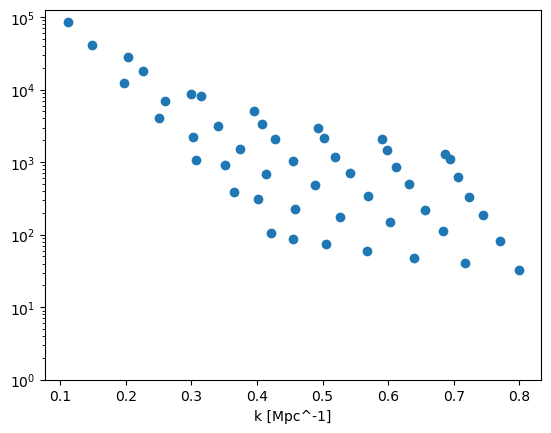

In [675]:
plt.scatter(kbins, pspec, marker='o')
plt.yscale('log'); plt.ylim(1e0, )
plt.xlabel('k [Mpc^-1]');

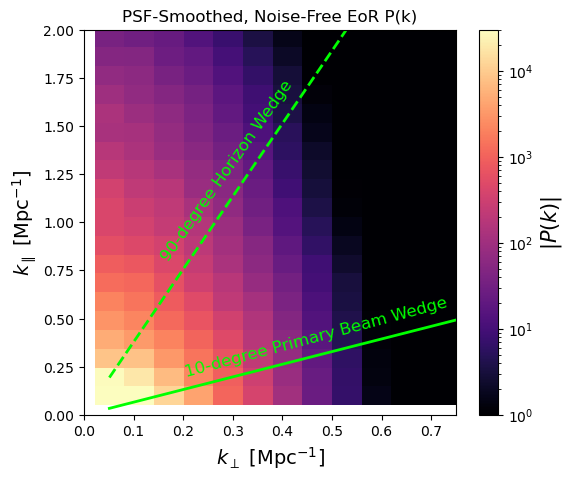

In [781]:
# show the wedge cuts
plt.figure(figsize=(6, 5))
# this comes from most recent run of get_pspec(): globals Pk
plt.pcolormesh(X, Y, Pk, cmap='magma', norm=colors.LogNorm(vmin=1e0, vmax=3e4))
plt.plot(kper_bins, kpar_beam_wedge, c='lime', lw=2)
plt.plot(kper_bins, kpar_horizon_wedge, c='lime', lw=2, ls='--')

cbar = plt.colorbar()
cbar.set_label(r"$|P(k)|$", fontsize=15)
plt.xlim(0, .75); plt.ylim(0, 2)
plt.xlabel(r'$k_\perp\ [{\rm Mpc}^{-1}]$', fontsize=14)
plt.ylabel(r'$k_\parallel\ [{\rm Mpc}^{-1}]$', fontsize=14)
plt.text(0.15, 0.8, '90-degree Horizon Wedge', c='lime', fontsize=12, rotation=55)
plt.text(0.2, 0.20, '10-degree Primary Beam Wedge', c='lime', fontsize=12, rotation=15)
plt.title('PSF-Smoothed, Noise-Free EoR P(k)')

#plt.savefig('SKA_EOR_2DPS_wedge_cuts.png', dpi=150, bbox_inches='tight')

Text(0, 0.5, '$k_\\parallel\\ [{\\rm Mpc}^{-1}]$')

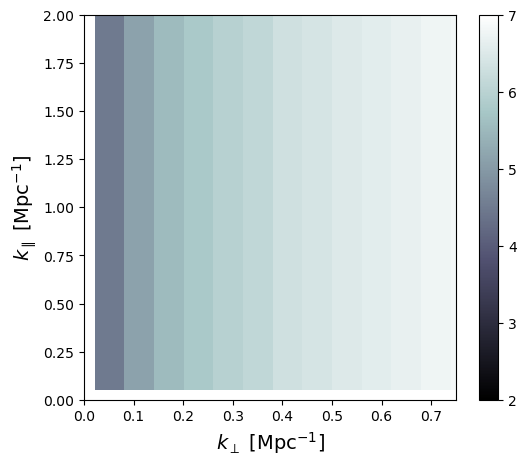

In [751]:
# show the wedge cut weights
plt.figure(figsize=(6, 5))
# this comes from most recent run of get_pspec(): globals wgts
plt.pcolormesh(X, Y, np.log10(wgts), vmin=2, vmax=7, cmap='bone')
plt.colorbar()
plt.xlim(0, .75); plt.ylim(0, 2)
plt.xlabel(r'$k_\perp\ [{\rm Mpc}^{-1}]$', fontsize=14)
plt.ylabel(r'$k_\parallel\ [{\rm Mpc}^{-1}]$', fontsize=14)

# run pspec estimation

Given the wedge cut defined above, compute power spectra for three different observational setups.

In [ ]:
%%time
PS_data = []

#for obs_time, subarray in zip([1000.], ['AAstar']):
for obs_time, subarray in zip([100., 1000., 1000.], ['AAstar', 'AAstar', 'AA4']):
    ps_data = {}
    for fpath in files:
        key = os.path.basename(fpath)[:-3].replace('Lightcone_', '').replace('_400_Samples', '')

        # compute pspec if FID or if this is the first pass
        if ("FID" in key) or (len(PS_data) == 0):
            pspec_1d = []
            Niter = 200
            for fi in range(Niter):
                kbins, pspec, pspec_var = get_pspec(fpath, idx=fi, add_noise='FID' in key, smooth_maps=True)
                pspec_1d.append(pspec)
            pspec_1d = np.array(pspec_1d)
        else:
            # for non-FID keys on second+ pass, just use previously computed (noise-free) pspec
            pspec_1d = PS_data[0][key]['ps_clean'].copy()
            kbins = PS_data[0][key]['ks'].copy()

        # insert power spectrum data
        ps_data[key] = {
            'ps_clean':  pspec_1d,
            'ks':  kbins,
        }

        if 'FID' in key:
            ps_data[key].update({
                'ps_obs': pspec_1d,
            })
            
    PS_data.append(ps_data)

Let's plot the convergence of the power spectra for the different lightcone realizations (without telescope noise).

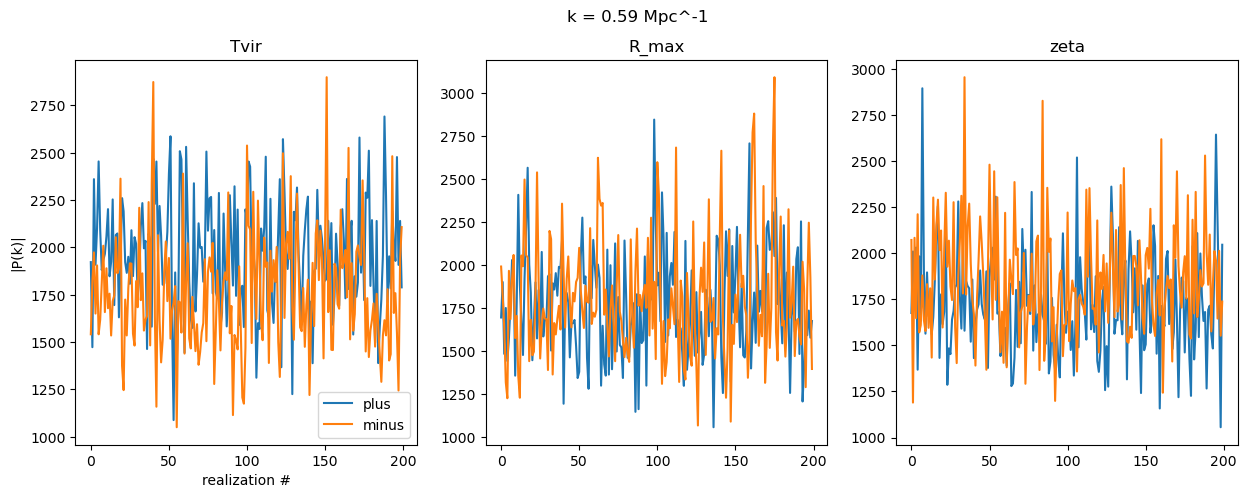

In [671]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ki = 35
axes[0].plot(ps_data['ION_Tvir_MIN_Plus']['ps_clean'][:, ki], label='plus');
axes[0].plot(ps_data['ION_Tvir_MIN_Minus']['ps_clean'][:, ki], label='minus');
axes[1].plot(ps_data['R_BUBBLE_MAX_Plus']['ps_clean'][:, ki]);
axes[1].plot(ps_data['R_BUBBLE_MAX_Minus']['ps_clean'][:, ki]);
axes[2].plot(ps_data['HII_EFF_FACTOR_Plus']['ps_clean'][:, ki]);
axes[2].plot(ps_data['HII_EFF_FACTOR_Minus']['ps_clean'][:, ki]);
axes[0].set_xlabel('realization #'); axes[0].set_ylabel('|P(k)|');
axes[0].set_title('Tvir'); axes[1].set_title('R_max'); axes[2].set_title('zeta')
fig.suptitle("k = {:.2f} Mpc^-1".format(kbins[ki]));
axes[0].legend();

Let's save the data b/c it takes a long time to run....

In [610]:
save_data = False
if save_data:
    np.savez(
        'PS_data_horizon_wedge.npz',
        PS_data=PS_data,
        obs_times=[100.,1000.,1000.],
        sub_arrays=['AAstar', 'AAstar', 'AA4'],
    )

Load the saved data if you already computed the PS.

In [ ]:
load_data = False
if load_data:
    PS_data = np.load('PS_data_10deg_wedge.npz', allow_pickle=True)['PS_data']

# compute the fisher matrix

In [611]:
# Compute the finite‐difference derivatives for each k‐bin & sample
# from the statistics derived from the clean signal
PS_derivs = []
for ps_data in PS_data:
    dPS = []
    for ip, param in enumerate(params):
        dPS.append((ps_data[f'{param}_Plus']['ps_clean'] - ps_data[f'{param}_Minus']['ps_clean']) / delta_params[ip])
    PS_derivs.append(np.array(dPS))
ks = ps_data[f'{param}_Plus']['ks']

In [612]:
## Whitening step ##
PS_derivs_white = []
covariances = []
for i, ps_derivs in enumerate(PS_derivs):
    ps_fid = PS_data[i]['FID']['ps_obs'] 
    std_fid = np.std(ps_fid, axis=0)

    # remove modes above smoothing limit where there is no variance
    mask = std_fid > 1e-5
    white_fid = ps_fid[:, mask]/std_fid[mask]
    ks = PS_data[i]['FID']['ks'][mask]

    # Whitening the derivatives
    ps_derivs_white = ps_derivs[..., mask]/std_fid[mask]
    
    PS_derivs_white.append(ps_derivs_white)
    
    cov = np.cov(white_fid, rowvar=False)
    #cov = np.eye(len(cov)) * cov
    print(f'log Condition number of the covariance matrix: {np.log10(np.linalg.cond(cov)):.2f} (should be <= 7).')
    covariances.append(cov)

log Condition number of the covariance matrix: 0.72 (should be <= 7).
log Condition number of the covariance matrix: 0.61 (should be <= 7).
log Condition number of the covariance matrix: 0.72 (should be <= 7).


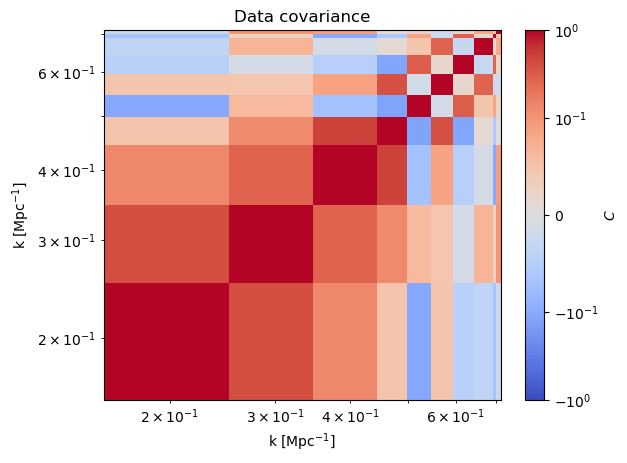

In [613]:
plt.figure()
plt.pcolormesh(ks, ks, covariances[0], cmap='coolwarm', norm=colors.SymLogNorm(linthresh=.1, vmin=-1., vmax=1.))
plt.xscale('log')
plt.yscale('log')
plt.title('Data covariance')
plt.xlabel('k [Mpc$^{-1}$]')
plt.ylabel('k [Mpc$^{-1}$]')
plt.colorbar(label=r'$C$')

In [614]:
# get fisher matrices and their inverses
PS_Fisher_Inv = []
for k, ps_derivs_white in enumerate(PS_derivs_white):

    ps_fisher = np.zeros((nparams, nparams))
    
    deriv_sample = np.mean(ps_derivs_white, axis=1)
    for i in range(nparams):
        for j in range(nparams):  
            ps_fisher[i, j] = np.dot(
                deriv_sample[i],
                np.dot(np.linalg.pinv(covariances[k], rcond=1e-15),
                       deriv_sample[j])
            )

    # compute mean of fisher matrix and then its inverse
    ps_fisher_inv = np.linalg.pinv(ps_fisher, rcond=1e-15)
    PS_Fisher_Inv.append(ps_fisher_inv)

In [615]:
np.savez("PS_Fisher_Inv_horizon_wedge.npz",
         PS_Fisher_Inv=PS_Fisher_Inv,
         obs_times=[100.,1000.,1000.],
         sub_arrays=['AAstar', 'AAstar', 'AA4'],
         params=params,
         fid=fid,
)

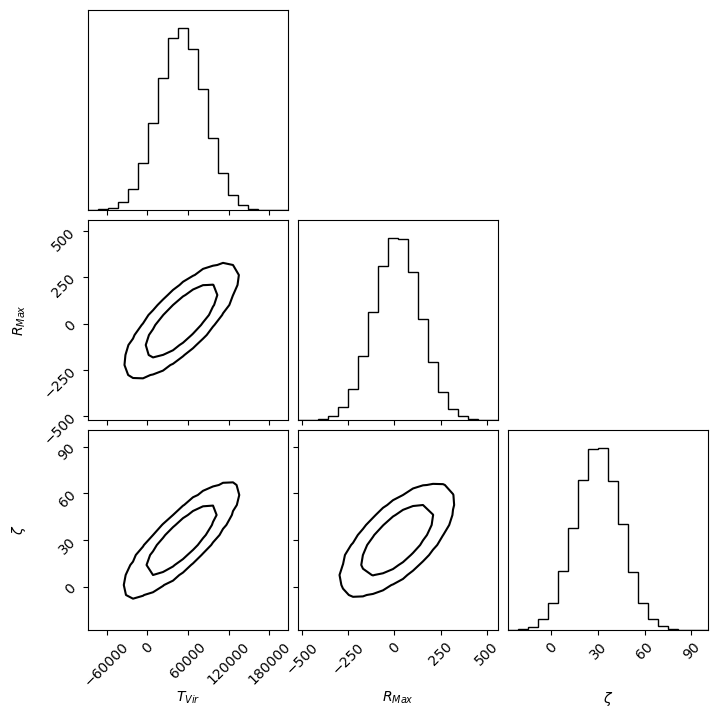

In [616]:
fisher_data = np.random.multivariate_normal(fid, PS_Fisher_Inv[2], size=100000)

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68, 0.95),
    plot_density=False,
    smooth=.5,
)

# plot contours

Just plot 68% confidence intervals 

In [652]:
# Astro params
params = ['ION_Tvir_MIN','R_BUBBLE_MAX','HII_EFF_FACTOR']
Fisher_Param = [r'$T_{Vir}/ \theta_0$',r'$R_{Max}/ \theta_0$',r'$\zeta/ \theta_0$']
nparams = len(params)
# parameter values for fiducial simulation
fid = np.array([pow(10,4.7),15,30])

In [653]:
fisher_no_wedge = np.load('PS_Fisher_Inv_no_wedge.npz')['PS_Fisher_Inv']
fisher_beam_wedge = np.load('PS_Fisher_Inv_10deg_wedge.npz')['PS_Fisher_Inv']
fisher_horizon_wedge = np.load('PS_Fisher_Inv_horizon_wedge.npz')['PS_Fisher_Inv']

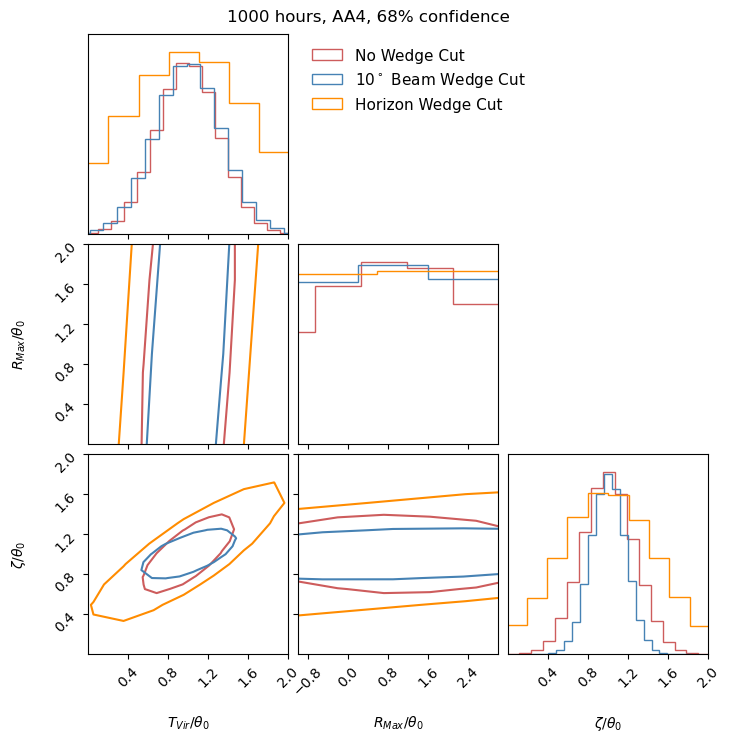

In [784]:
# plot AA4 contours
fisher_data = np.random.multivariate_normal(fid, fisher_no_wedge[2], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    color='indianred',
)

fisher_data = np.random.multivariate_normal(fid, fisher_beam_wedge[2], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    fig=fig,
    color='steelblue',
)

fisher_data = np.random.multivariate_normal(fid, fisher_horizon_wedge[2], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    fig=fig,
    color='darkorange',
)

fig.axes[1].legend(list(fig.axes[0].patches), ['No Wedge Cut', r'$10^\circ$ Beam Wedge Cut', 'Horizon Wedge Cut'], fontsize=11, loc=2, framealpha=0)
fig.axes[0].set_xlim(0, 2); fig.axes[4].set_xlim(-1, 3); fig.axes[8].set_xlim(0, 2)
fig.axes[3].set_xlim(0, 2); fig.axes[3].set_ylim(0, 2)
fig.axes[6].set_xlim(0, 2); fig.axes[6].set_ylim(0, 2)
fig.axes[7].set_xlim(-1, 3); fig.axes[7].set_ylim(0, 2)

fig.suptitle('1000 hours, AA4, 68% confidence');

#fig.savefig('SKA_EOR_2DPS_1000hr_AA4.png', dpi=150, bbox_inches='tight')

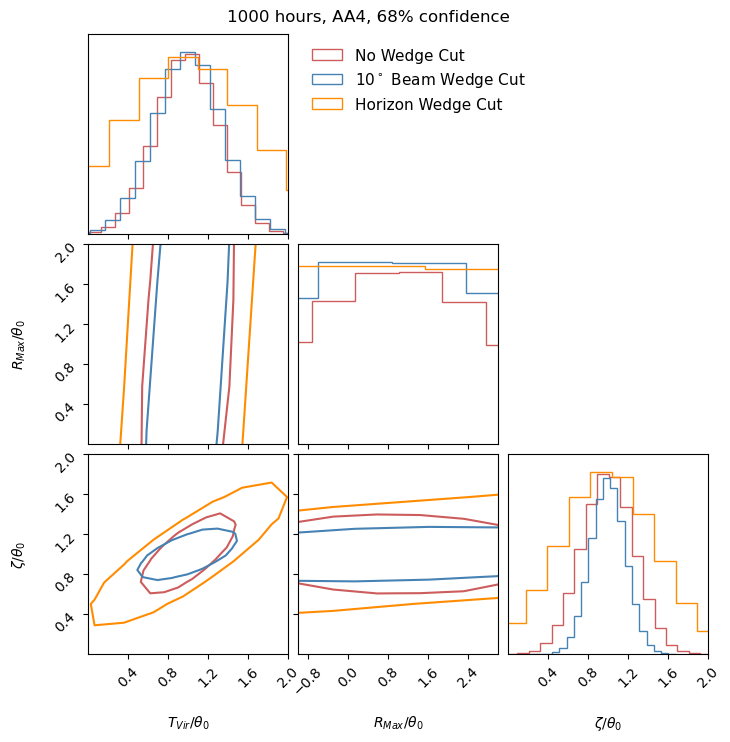

In [785]:
# plot AA4 contours
fisher_data = np.random.multivariate_normal(fid, fisher_no_wedge[2], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    color='indianred',
)

fisher_data = np.random.multivariate_normal(fid, fisher_beam_wedge[2], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    fig=fig,
    color='steelblue',
)

fisher_data = np.random.multivariate_normal(fid, fisher_horizon_wedge[2], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    fig=fig,
    color='darkorange',
)

fig.axes[1].legend(list(fig.axes[0].patches), ['No Wedge Cut', r'$10^\circ$ Beam Wedge Cut', 'Horizon Wedge Cut'], fontsize=11, loc=2, framealpha=0)
fig.axes[0].set_xlim(0, 2); fig.axes[4].set_xlim(-1, 3); fig.axes[8].set_xlim(0, 2)
fig.axes[3].set_xlim(0, 2); fig.axes[3].set_ylim(0, 2)
fig.axes[6].set_xlim(0, 2); fig.axes[6].set_ylim(0, 2)
fig.axes[7].set_xlim(-1, 3); fig.axes[7].set_ylim(0, 2)

fig.suptitle('1000 hours, AA4, 68% confidence')

#fig.savefig('SKA_EOR_2DPS_1000hr_AA4.png', dpi=150, bbox_inches='tight')

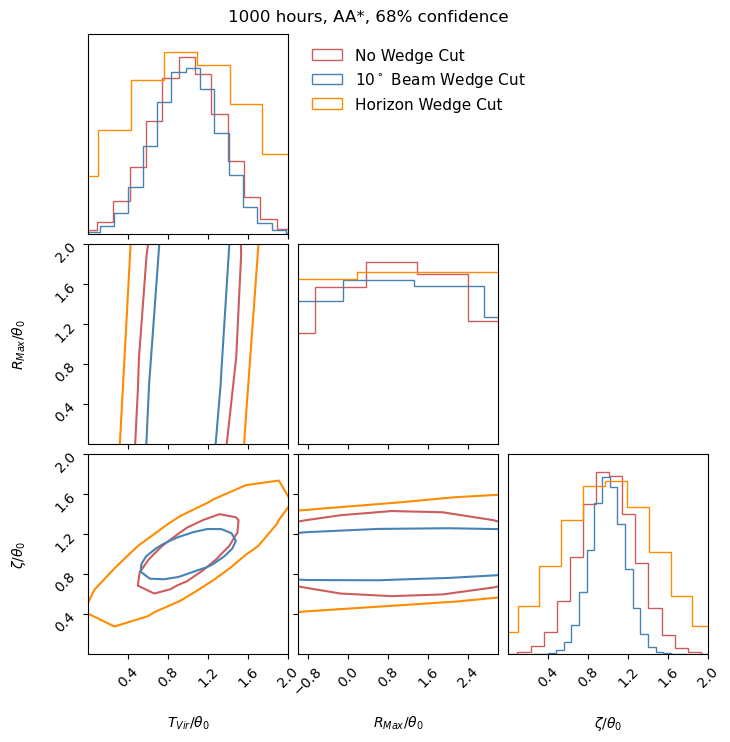

In [786]:
# plot AA4 contours
fisher_data = np.random.multivariate_normal(fid, fisher_no_wedge[1], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    color='indianred',
)

fisher_data = np.random.multivariate_normal(fid, fisher_beam_wedge[1], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    fig=fig,
    color='steelblue',
)

fisher_data = np.random.multivariate_normal(fid, fisher_horizon_wedge[1], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    fig=fig,
    color='darkorange',
)

fig.axes[1].legend(list(fig.axes[0].patches), ['No Wedge Cut', r'$10^\circ$ Beam Wedge Cut', 'Horizon Wedge Cut'], fontsize=11, loc=2, framealpha=0)
fig.axes[0].set_xlim(0, 2); fig.axes[4].set_xlim(-1, 3); fig.axes[8].set_xlim(0, 2)
fig.axes[3].set_xlim(0, 2); fig.axes[3].set_ylim(0, 2)
fig.axes[6].set_xlim(0, 2); fig.axes[6].set_ylim(0, 2)
fig.axes[7].set_xlim(-1, 3); fig.axes[7].set_ylim(0, 2)

fig.suptitle('1000 hours, AA*, 68% confidence')

#fig.savefig('SKA_EOR_2DPS_1000hr_AAstar.png', dpi=150, bbox_inches='tight')

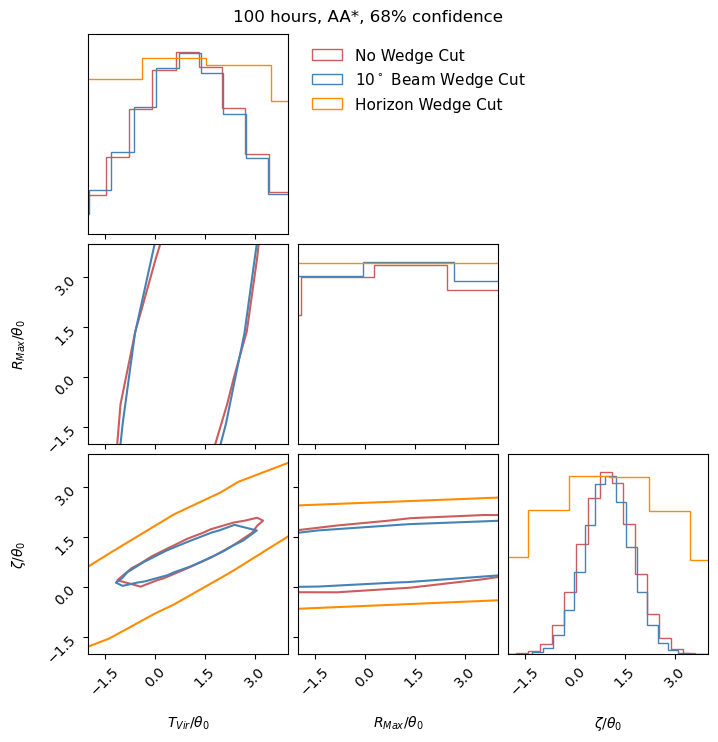

In [787]:
# plot AA4 contours
fisher_data = np.random.multivariate_normal(fid, fisher_no_wedge[0], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    color='indianred',
)

fisher_data = np.random.multivariate_normal(fid, fisher_beam_wedge[0], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    fig=fig,
    color='steelblue',
)

fisher_data = np.random.multivariate_normal(fid, fisher_horizon_wedge[0], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    fig=fig,
    color='darkorange',
)

fig.axes[1].legend(list(fig.axes[0].patches), ['No Wedge Cut', r'$10^\circ$ Beam Wedge Cut', 'Horizon Wedge Cut'], fontsize=11, loc=2, framealpha=0)
fig.axes[0].set_xlim(-2, 4); fig.axes[4].set_xlim(-2, 4); fig.axes[8].set_xlim(-2, 4)
fig.axes[3].set_xlim(-2, 4); fig.axes[3].set_ylim(-2, 4)
fig.axes[6].set_xlim(-2, 4); fig.axes[6].set_ylim(-2, 4)
fig.axes[7].set_xlim(-2, 4); fig.axes[7].set_ylim(-2, 4)

fig.suptitle('100 hours, AA*, 68% confidence')

#fig.savefig('SKA_EOR_2DPS_100hr_AAstar.png', dpi=150, bbox_inches='tight')

Now hold wedge cut fixed and plot different telescopes.

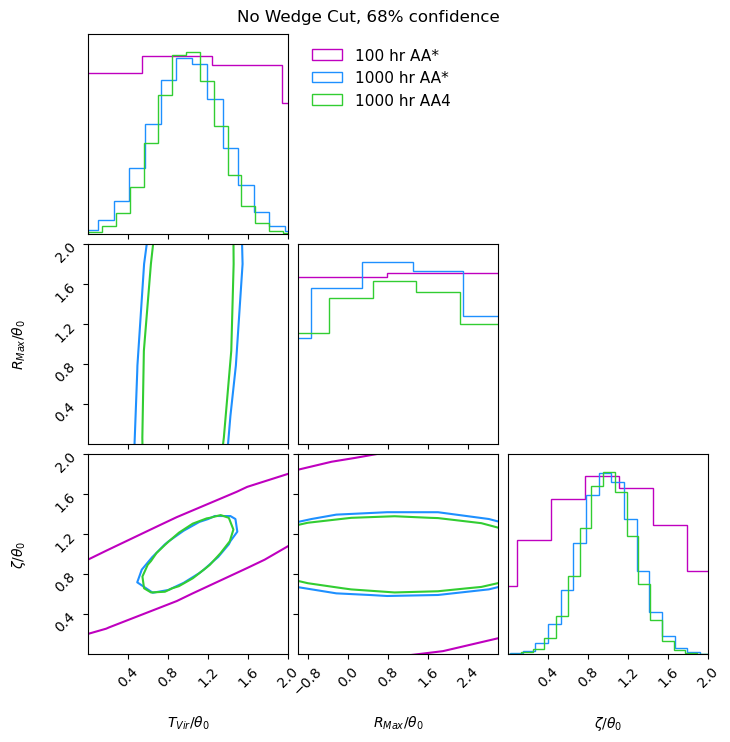

In [788]:
# plot no wedge cut
fisher_data = np.random.multivariate_normal(fid, fisher_no_wedge[0], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    color='m',
)

fisher_data = np.random.multivariate_normal(fid, fisher_no_wedge[1], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    fig=fig,
    color='dodgerblue',
)

fisher_data = np.random.multivariate_normal(fid, fisher_no_wedge[2], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    fig=fig,
    color='limegreen',
)

fig.axes[1].legend(list(fig.axes[0].patches), ['100 hr AA*', '1000 hr AA*', '1000 hr AA4'], fontsize=11, loc=2, framealpha=0)
fig.axes[0].set_xlim(0, 2); fig.axes[4].set_xlim(-1, 3); fig.axes[8].set_xlim(0, 2)
fig.axes[3].set_xlim(0, 2); fig.axes[3].set_ylim(0, 2)
fig.axes[6].set_xlim(0, 2); fig.axes[6].set_ylim(0, 2)
fig.axes[7].set_xlim(-1, 3); fig.axes[7].set_ylim(0, 2)

fig.suptitle('No Wedge Cut, 68% confidence')

#fig.savefig('SKA_EOR_2DPS_no_wedge_cut.png', dpi=150, bbox_inches='tight')

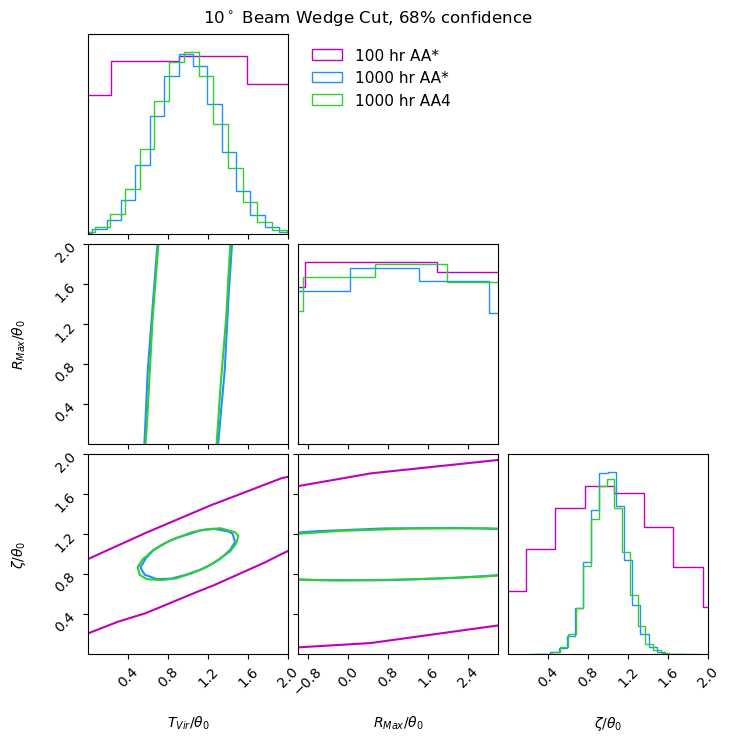

In [789]:
# plot beam wedge cut
fisher_data = np.random.multivariate_normal(fid, fisher_beam_wedge[0], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    color='m',
)

fisher_data = np.random.multivariate_normal(fid, fisher_beam_wedge[1], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    fig=fig,
    color='dodgerblue',
)

fisher_data = np.random.multivariate_normal(fid, fisher_beam_wedge[2], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    fig=fig,
    color='limegreen',
)

fig.axes[1].legend(list(fig.axes[0].patches), ['100 hr AA*', '1000 hr AA*', '1000 hr AA4'], fontsize=11, loc=2, framealpha=0)
fig.axes[0].set_xlim(0, 2); fig.axes[4].set_xlim(-1, 3); fig.axes[8].set_xlim(0, 2)
fig.axes[3].set_xlim(0, 2); fig.axes[3].set_ylim(0, 2)
fig.axes[6].set_xlim(0, 2); fig.axes[6].set_ylim(0, 2)
fig.axes[7].set_xlim(-1, 3); fig.axes[7].set_ylim(0, 2)

fig.suptitle(r'$10^\circ$ Beam Wedge Cut, 68% confidence')

#fig.savefig('SKA_EOR_2DPS_beam_wedge_cut.png', dpi=150, bbox_inches='tight')

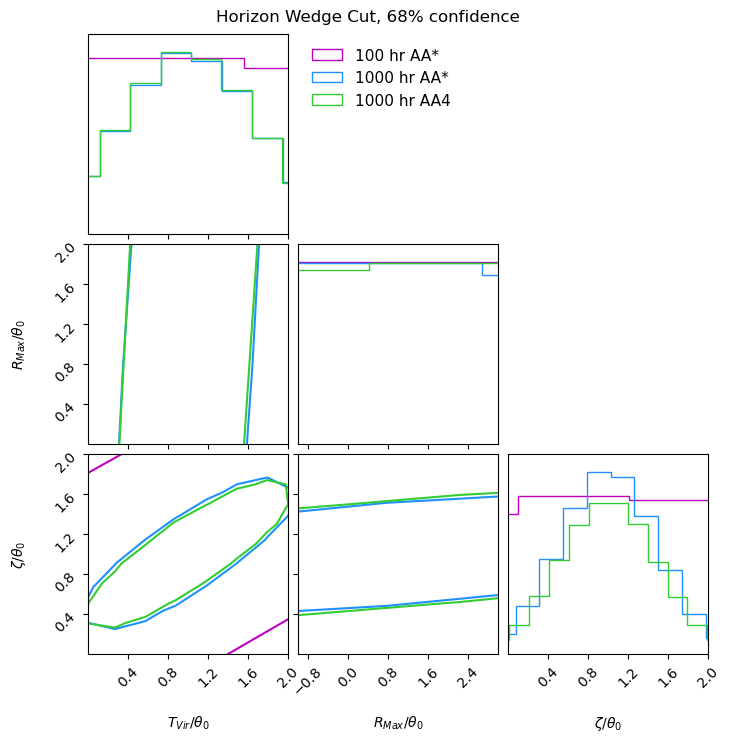

In [790]:
# plot horizon wedge cut
fisher_data = np.random.multivariate_normal(fid, fisher_horizon_wedge[0], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    color='m',
)

fisher_data = np.random.multivariate_normal(fid, fisher_horizon_wedge[1], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    fig=fig,
    color='dodgerblue',
)

fisher_data = np.random.multivariate_normal(fid, fisher_horizon_wedge[2], size=100000) / fid

fig = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,),
    plot_density=False,
    fig=fig,
    color='limegreen',
)

fig.axes[1].legend(list(fig.axes[0].patches), ['100 hr AA*', '1000 hr AA*', '1000 hr AA4'], fontsize=11, loc=2, framealpha=0)
fig.axes[0].set_xlim(0, 2); fig.axes[4].set_xlim(-1, 3); fig.axes[8].set_xlim(0, 2)
fig.axes[3].set_xlim(0, 2); fig.axes[3].set_ylim(0, 2)
fig.axes[6].set_xlim(0, 2); fig.axes[6].set_ylim(0, 2)
fig.axes[7].set_xlim(-1, 3); fig.axes[7].set_ylim(0, 2)

fig.suptitle(r'Horizon Wedge Cut, 68% confidence')

#fig.savefig('SKA_EOR_2DPS_horizon_wedge_cut.png', dpi=150, bbox_inches='tight')